In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

config_procesos = [
    (2019, 'MATE_ACTUAL'), 
    (2021, 'MATE_ACTUAL'), 
    (2024, 'MATE1_REG_ACTUAL'), 
    (2025, 'MATE1_REG_ACTUAL')
]

def obtener_datos_base(year, col):
    posibles_carpetas = [os.path.join('csv'), os.path.join('..', 'csv')]
    ruta_b = None
    for carpeta in posibles_carpetas:
        temp_path = os.path.join(carpeta, f'ArchivoB_Adm{year}.csv')
        if os.path.exists(temp_path):
            ruta_b = temp_path
            break
    if not ruta_b:
        raise FileNotFoundError(f"No se encontró ArchivoB_Adm{year}.csv")
    ruta_c = ruta_b.replace(f'ArchivoB_Adm{year}', f'ArchivoC_Adm{year}')
    df_b = pd.read_csv(ruta_b, sep=';', usecols=['ID_aux', 'SEXO'], low_memory=False)
    df_c = pd.read_csv(ruta_c, sep=';', usecols=['ID_aux', col], low_memory=False)
    df = pd.merge(df_c, df_b, on='ID_aux')
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df, col

colores_genero = {'Hombre': '#1b9e77', 'Mujer': '#d95f02'} # Teal y Naranja

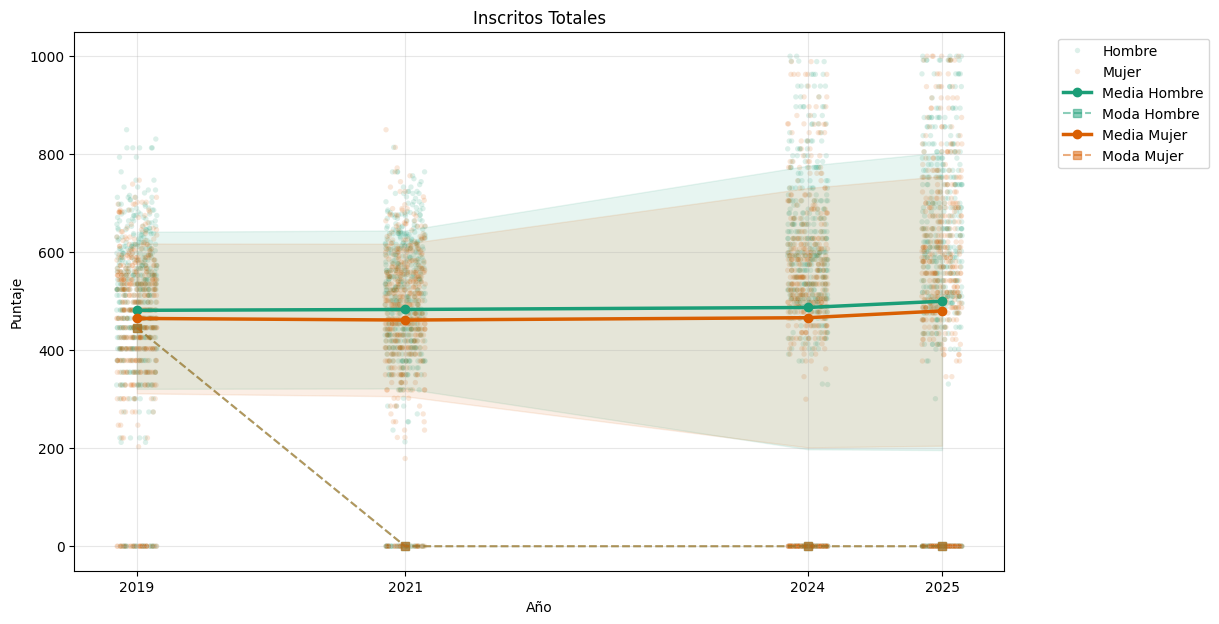

In [2]:
stats_all, points_all = [], []

for year, col in config_procesos:
    try:
        df, math_col = obtener_datos_base(year, col)
        df[math_col] = df[math_col].fillna(0) 

        for g_val, g_name in [(1, 'Hombre'), (2, 'Mujer')]:
            sub = df[df['SEXO'] == g_val][math_col]
            if sub.empty: continue
            mean, std = sub.mean(), sub.std()
            mode = sub.mode().iloc[0] if not sub.mode().empty else 0
            stats_all.append({'Año': year, 'Género': g_name, 'Media': mean, 
                              'Moda': mode, 'Std_Sup': mean + std, 'Std_Inf': mean - std})
            
            pts = sub.sample(n=min(500, len(sub))).to_frame(name='Puntaje')
            pts['Año_Jitter'] = year + np.random.uniform(-0.15, 0.15, size=len(pts))
            pts['Género'] = g_name
            points_all.append(pts)
    except Exception as e:
        print(f"⚠️ Error {year}: {e}")

if len(points_all) > 0:
    df_stats_all = pd.DataFrame(stats_all)
    df_pts_all = pd.concat(points_all)

    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=df_pts_all, x='Año_Jitter', y='Puntaje', hue='Género', 
                    alpha=0.15, palette=colores_genero, s=15)
    
    for g, color in colores_genero.items():
        data = df_stats_all[df_stats_all['Género'] == g]
        plt.plot(data['Año'], data['Media'], marker='o', color=color, lw=2.5, label=f'Media {g}')
        plt.plot(data['Año'], data['Moda'], marker='s', ls='--', color=color, alpha=0.5, label=f'Moda {g}')
        plt.fill_between(data['Año'], data['Std_Inf'], data['Std_Sup'], color=color, alpha=0.1)

    # Etiquetas
    plt.title('Inscritos Totales')
    plt.xlabel('Año')
    plt.ylabel('Puntaje')
    plt.xticks([2019, 2021, 2024, 2025])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

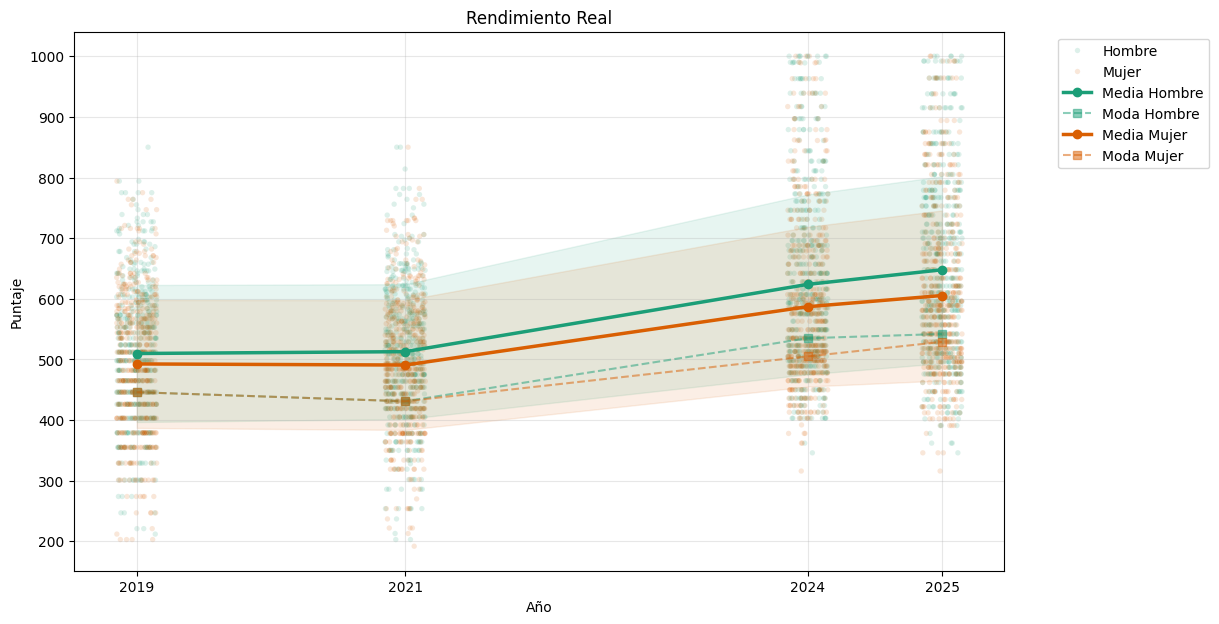

In [3]:
stats_filt, points_filt = [], []

for year, col in config_procesos:
    try:
        df, math_col = obtener_datos_base(year, col)
        df = df[df[math_col] > 0] 

        for g_val, g_name in [(1, 'Hombre'), (2, 'Mujer')]:
            sub = df[df['SEXO'] == g_val][math_col]
            if sub.empty: continue
            mean, std = sub.mean(), sub.std()
            mode = sub.mode().iloc[0] if not sub.mode().empty else mean
            stats_filt.append({'Año': year, 'Género': g_name, 'Media': mean, 
                               'Moda': mode, 'Std_Sup': mean + std, 'Std_Inf': mean - std})
            
            pts = sub.sample(n=min(500, len(sub))).to_frame(name='Puntaje')
            pts['Año_Jitter'] = year + np.random.uniform(-0.15, 0.15, size=len(pts))
            pts['Género'] = g_name
            points_filt.append(pts)
    except Exception as e:
        print(f"⚠️ Error {year}: {e}")

if len(points_filt) > 0:
    df_stats_filt = pd.DataFrame(stats_filt)
    df_pts_filt = pd.concat(points_filt)

    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=df_pts_filt, x='Año_Jitter', y='Puntaje', hue='Género', 
                    alpha=0.15, palette=colores_genero, s=15)
    
    for g, color in colores_genero.items():
        data = df_stats_filt[df_stats_filt['Género'] == g]
        plt.plot(data['Año'], data['Media'], marker='o', color=color, lw=2.5, label=f'Media {g}')
        plt.plot(data['Año'], data['Moda'], marker='s', ls='--', color=color, alpha=0.5, label=f'Moda {g}')
        plt.fill_between(data['Año'], data['Std_Inf'], data['Std_Sup'], color=color, alpha=0.1)

    # Etiquetas
    plt.title('Rendimiento Real')
    plt.xlabel('Año')
    plt.ylabel('Puntaje')
    plt.xticks([2019, 2021, 2024, 2025])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()